## Evaluating uplift models using ranking-based metrics across real datasets
## Abstract

Understanding whether a treatment works on average is often insufficient for real-world decision-making. In many applications, the key question is which individuals or segments benefit most from an intervention.  

This post explores **Conditional Average Treatment Effect (CATE)** estimation, focusing on practical modeling approaches, evaluation under unobserved individual effects, and how uplift-based ranking translates into actionable targeting decisions. The emphasis is on bridging causal estimation with real-world deployment considerations.

---

## Understanding Treatment Sensitivity with CATE

In many real-world decision problems, the key question is not whether an intervention works on average, but **who it works for**.

In marketing and credit risk settings, the same treatment can:
- significantly improve outcomes for some customers  
- have no measurable impact on others  
- or even lead to negative effects in certain segments  

This makes **heterogeneous treatment effects**(HTE) central to effective decision-making.

This post focuses on estimating **Conditional Average Treatment Effects (CATE)** to identify which groups are most responsive to a given intervention.

We explore:

- how treatment effects vary across customer segments  
- how to estimate CATE using standard machine learning approaches  
- how to evaluate models when true individual effects are unobservable  
- how ranking-based evaluation supports practical targeting decisions  

The goal is not just to estimate effects, but to understand how these estimates translate into **actionable decisions**.

---

## Data

We use publicly available datasets to ensure reproducibility:

- **Bank Marketing (OpenML)** — marketing response prediction  
- **German Credit (OpenML)** — credit risk classification  

If external access fails (e.g., firewall or network issues), a **synthetic dataset** is generated to preserve the full modeling and evaluation pipeline.

---

## Practical Setup

- Standard machine learning pipelines for outcome modeling  
- Ranking-based evaluation to assess treatment effect usefulness  
- Focus on deployment-oriented interpretation rather than theoretical optimality  

---

## References

- Causal Inference in Python: Applying Causal Inference in the Tech Industry by Facure, Matheus 
- OpenML datasets (Bank Marketing, German Credit)  
- scikit-learn documentation


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)
plt.rcParams["figure.figsize"] = (9, 5)


### Effect Diagnostics

These functions measure whether model scores successfully separate customers by treatment benefit.

Since individual treatment effect is unobserved, we evaluate whether predicted ranking aligns with observed group-level treatment differences.


In [2]:

def effect_binary(df: pd.DataFrame, y: str = "y", t: str = "t") -> float:
    treated = df.loc[df[t] == 1, y]
    control = df.loc[df[t] == 0, y]
    if len(treated) == 0 or len(control) == 0:
        return np.nan
    return treated.mean() - control.mean()


def effect_by_quantile(df: pd.DataFrame, score_col: str, q: int = 10, y: str = "y", t: str = "t") -> pd.DataFrame:
    quant = pd.qcut(df[score_col], q=q, labels=False, duplicates="drop")
    rows = []
    for k in sorted(quant.dropna().unique()):
        g = df.loc[quant == k]
        rows.append({
            "quantile": int(k),
            "n": len(g),
            "score_mean": g[score_col].mean(),
            "effect": effect_binary(g, y=y, t=t)
        })
    return pd.DataFrame(rows).sort_values("score_mean")


def cumulative_effect_curve(df: pd.DataFrame, score_col: str, steps: int = 100, y: str = "y", t: str = "t"):
    df_sorted = df.sort_values(score_col, ascending=False).reset_index(drop=True)
    n = len(df_sorted)
    cutoffs = np.linspace(max(1, n // steps), n, steps).astype(int)
    cutoffs = np.unique(np.clip(cutoffs, 1, n))
    x = 100 * cutoffs / n
    effects = [effect_binary(df_sorted.iloc[:c], y=y, t=t) for c in cutoffs]
    return x, np.array(effects)


def cumulative_gain_curve(df: pd.DataFrame, score_col: str, steps: int = 100, y: str = "y", t: str = "t", normalize: bool = True):
    x, ce = cumulative_effect_curve(df, score_col, steps=steps, y=y, t=t)
    p = x / 100.0
    ate = effect_binary(df, y=y, t=t)
    gain = p * (ce - ate) if normalize else p * ce
    auc = np.trapezoid(gain, p)
    return x, gain, auc, ate


def pseudo_outcome_transformed(y, t, e, clip=1e-3):
    e = np.clip(e, clip, 1 - clip)
    return (t * y / e) - ((1 - t) * y / (1 - e))


def weighted_mse(y_true, y_pred, w):
    return np.average((y_true - y_pred) ** 2, weights=w)


### Code Context — Dataset Preparation

HTE methods require:
• Covariates (X)  
• Treatment indicator (T)  
• Outcome (Y)  
HTE estimation works on both experimental and observational data if assumptions hold.


In [3]:

def load_openml_or_fallback(name: str, fallback_n: int = 20000, seed: int = 0):
    rng = np.random.default_rng(seed)
    try:
        data = fetch_openml(name=name, as_frame=True, version=1)
        X = data.data.copy()
        y_raw = data.target.copy()
        return X, y_raw, "openml"
    except Exception as e:
        n = fallback_n
        X = pd.DataFrame({
            "age": rng.integers(18, 80, size=n),
            "income": rng.normal(60000, 20000, size=n).clip(5000, 200000),
            "balance": rng.normal(1500, 1200, size=n).clip(0, 15000),
            "channel": rng.choice(["branch", "web", "mobile", "call"], size=n, p=[0.2, 0.35, 0.35, 0.1]),
            "segment": rng.choice(["A", "B", "C"], size=n, p=[0.3, 0.5, 0.2]),
            "region": rng.choice(["NE", "MW", "S", "W"], size=n),
        })
        logit = (
            -2.0
            + 0.015*(X["age"] - 40)
            + 0.00002*(X["income"] - 60000)
            + 0.0006*(X["balance"] - 1500)
            + (X["channel"].eq("mobile")*0.3).astype(float)
            + (X["segment"].eq("A")*0.2).astype(float)
        )
        p = 1 / (1 + np.exp(-logit))
        y_raw = pd.Series(rng.binomial(1, p), name="y_raw")
        return X, y_raw, f"fallback (OpenML error: {type(e).__name__})"


### Constructing a Heterogeneous Treatment World

This step simulates:
• Treatment assignment  
• Individual-level treatment heterogeneity  
Treatment is assigned via a learned propensity model, while heterogeneous effects are injected through a nonlinear transformation of features, creating a controlled but confounded uplift setting.


In [4]:

def make_preprocessor(X: pd.DataFrame):
    cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
    num_cols = X.select_dtypes(exclude=["object", "category"]).columns.tolist()

    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])
    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    return ColumnTransformer([
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols)
    ])

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def simulate_uplift_problem(X: pd.DataFrame, y_raw_binary: pd.Series, seed: int = 0):
    rng = np.random.default_rng(seed)
    pre = make_preprocessor(X)

    Z = pre.fit_transform(X)
    w_prop = rng.normal(size=Z.shape[1])
    z_prop = (Z @ w_prop).A1 if hasattr(Z, "A1") else (Z @ w_prop)

    # propensity e(x)
    e_true = sigmoid(0.6 * (z_prop / (np.std(z_prop) + 1e-9)))
    t = rng.binomial(1, e_true)

    # estimate e_hat
    prop_model = Pipeline([
        ("pre", pre),
        ("clf", LogisticRegression(max_iter=300))
    ])
    prop_model.fit(X, t)
    e_hat = prop_model.predict_proba(X)[:, 1]

    # heterogeneous effect tau(x)
    w_tau = rng.normal(size=Z.shape[1])
    z_tau = (Z @ w_tau).A1 if hasattr(Z, "A1") else (Z @ w_tau)
    true_tau = 0.7 * sigmoid(z_tau / (np.std(z_tau) + 1e-9))  # [0, 0.7]

    # baseline anchored to label prevalence + feature variation
    p0 = float(np.clip(y_raw_binary.mean(), 1e-4, 1 - 1e-4))
    base_logit = np.log(p0 / (1 - p0))
    base_logit = base_logit + 0.25 * (z_prop / (np.std(z_prop) + 1e-9))

    # observed outcome under treatment
    logit = base_logit + t * true_tau
    y = rng.binomial(1, sigmoid(logit))

    df = X.copy()
    df["y"] = y.astype(int)
    df["t"] = t.astype(int)
    df["e_hat"] = e_hat
    df["true_tau"] = true_tau
    return df


### Estimating Counterfactual Outcome Functions

Models are trained to approximate:

Expected outcome if treated  
Expected outcome if untreated  

Their difference produces an estimate of heterogeneous treatment effect.

Outcome modeling is the core computational strategy for estimating heterogeneous effects.


In [5]:

def outcome_model_score(df: pd.DataFrame):
    X = df.drop(columns=["y", "t", "e_hat", "true_tau"])
    y = df["y"].values
    pre = make_preprocessor(X)
    model = RandomForestClassifier(n_estimators=300, min_samples_leaf=50, random_state=0, n_jobs=-1)
    pipe = Pipeline([("pre", pre), ("model", model)])
    pipe.fit(X, y)
    return pipe.predict_proba(X)[:, 1]

def fit_outcome_model_subset(df_subset: pd.DataFrame):
    X = df_subset.drop(columns=["y", "t", "e_hat", "true_tau"])
    y = df_subset["y"].values
    pre = make_preprocessor(X)
    model = RandomForestClassifier(n_estimators=250, min_samples_leaf=50, random_state=0, n_jobs=-1)
    pipe = Pipeline([("pre", pre), ("model", model)])
    pipe.fit(X, y)
    return pipe

def t_learner_cate_score(df: pd.DataFrame):
    treated = df[df["t"] == 1]
    control = df[df["t"] == 0]
    m1 = fit_outcome_model_subset(treated)
    m0 = fit_outcome_model_subset(control)
    X_all = df.drop(columns=["y", "t", "e_hat", "true_tau"])
    mu1 = m1.predict_proba(X_all)[:, 1]
    mu0 = m0.predict_proba(X_all)[:, 1]
    return mu1 - mu0

def add_scores(df: pd.DataFrame, seed: int = 0):
    rng = np.random.default_rng(seed)
    out = df.copy()
    out["rand_score"] = rng.normal(size=len(out))
    out["y_score"] = outcome_model_score(out)
    out["cate_score"] = t_learner_cate_score(out)
    return out


### Visualization of Heterogeneous Effect Quality

Plots evaluate whether predicted heterogeneous effects produce meaningful treatment separation.

HTE usefulness is measured through decision quality, not prediction accuracy alone.


In [6]:

def plot_effect_by_quantile(df, title, q=10):
    plt.figure()
    for s in ["rand_score", "y_score", "cate_score"]:
        tab = effect_by_quantile(df, score_col=s, q=q)
        plt.plot(tab["score_mean"], tab["effect"], marker="o", label=s)
    plt.axhline(effect_binary(df), linestyle="--", color="black", label="ATE")
    plt.xlabel("Mean score in quantile (low → high)")
    plt.ylabel("Estimated effect within quantile")
    plt.title(title)
    plt.legend()
    plt.show()

def plot_cumulative_effect(df, title):
    plt.figure()
    ate = effect_binary(df)
    for s in ["rand_score", "y_score", "cate_score"]:
        x, ce = cumulative_effect_curve(df, s, steps=80)
        plt.plot(x, ce, label=s)
    plt.axhline(ate, linestyle="--", color="black", label="ATE")
    plt.xlabel("Top % of population (ranked by score)")
    plt.ylabel("Effect among top-% subset")
    plt.title(title)
    plt.legend()
    plt.show()

def plot_cumulative_gain(df, title):
    plt.figure()
    aucs = {}
    for s in ["rand_score", "y_score", "cate_score"]:
        x, g, auc, _ = cumulative_gain_curve(df, s, steps=80, normalize=True)
        aucs[s] = auc
        plt.plot(x, g, label=f"{s} (AUC={auc:.4f})")
    plt.axhline(0, linestyle="--", color="black", label="ATE baseline (normalized)")
    plt.xlabel("Top % of population (ranked by score)")
    plt.ylabel("Normalized cumulative gain")
    plt.title(title)
    plt.legend()
    plt.show()
    return aucs


### End-to-End HTE Estimation

Pipeline steps:
Data → Treatment → Outcome → Counterfactual outcome estimation → Effect ranking

This operationalizes heterogeneous effect estimation in practice.


In [7]:

X_bank, y_bank_raw, bank_source = load_openml_or_fallback("bank-marketing", seed=1)
print("Bank data source:", bank_source)

y_bank_str = y_bank_raw.astype(str).str.lower()
y_bank = y_bank_str.isin(["yes", "1", "true"]).astype(int)

bank_df = simulate_uplift_problem(X_bank, y_bank, seed=11)
bank_scored = add_scores(bank_df, seed=111)

print("Outcome rate:", bank_scored["y"].mean())
print("Treatment rate:", bank_scored["t"].mean())
print("ATE:", effect_binary(bank_scored))


Bank data source: openml
Outcome rate: 0.8868638163278848
Treatment rate: 0.4281037800535268
ATE: 0.06168106138306939


### Bucketed Effect Visualization

Shows whether customers with higher predicted effect truly exhibit higher observed treatment benefit.

If model captures heterogeneity correctly, treatment effect should increase across predicted effect buckets.


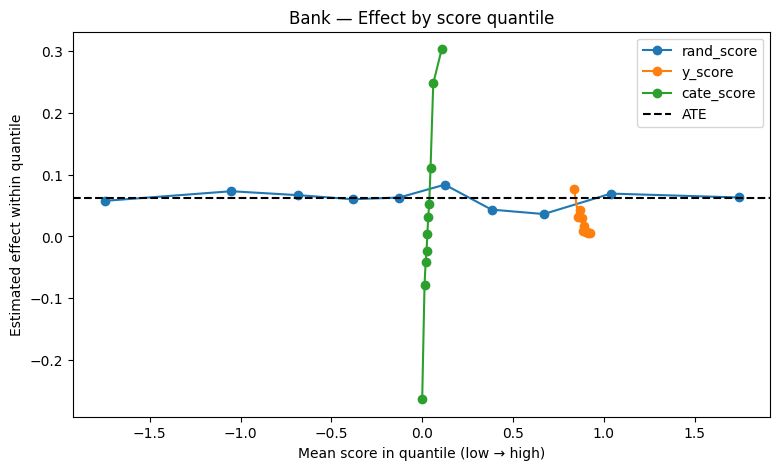

In [8]:

plot_effect_by_quantile(bank_scored, title="Bank — Effect by score quantile")


### Targeting Curve Interpretation

Shows expected benefit when targeting top predicted effect customers.

HTE modeling is primarily used for treatment allocation decisions.


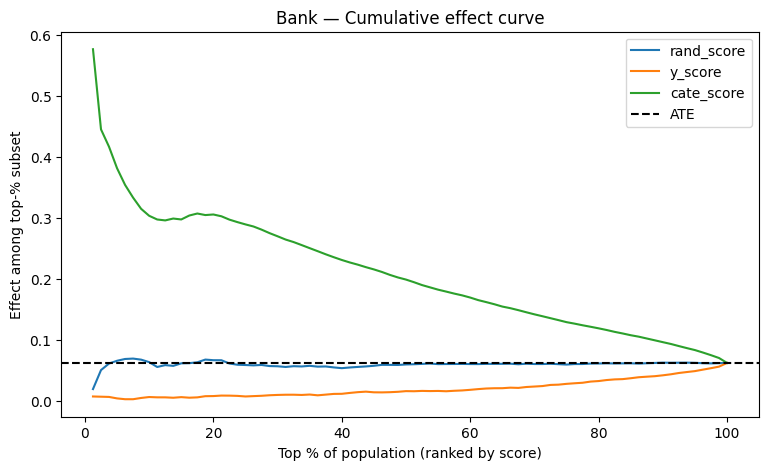

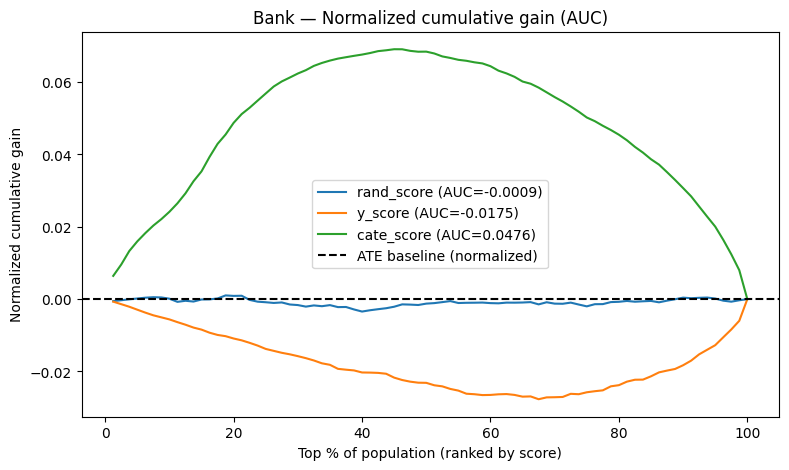

{'rand_score': np.float64(-0.0008504006781834974),
 'y_score': np.float64(-0.017501049915101506),
 'cate_score': np.float64(0.047550307185826986)}

In [9]:

plot_cumulative_effect(bank_scored, title="Bank — Cumulative effect curve")
bank_aucs = plot_cumulative_gain(bank_scored, title="Bank — Normalized cumulative gain (AUC)")
bank_aucs


### Repeating Analysis on New Data

Validates whether heterogeneous effect structure generalizes across datasets.

Heterogeneous effect estimation should not be dataset specific.


In [10]:

X_credit, y_credit_raw, credit_source = load_openml_or_fallback("credit-g", seed=2)
print("Credit data source:", credit_source)

y_credit_str = y_credit_raw.astype(str).str.lower()
y_credit = y_credit_str.isin(["good", "1", "true", "yes"]).astype(int)

credit_df = simulate_uplift_problem(X_credit, y_credit, seed=22)
credit_scored = add_scores(credit_df, seed=222)

print("Outcome rate:", credit_scored["y"].mean())
print("Treatment rate:", credit_scored["t"].mean())
print("ATE:", effect_binary(credit_scored))


Credit data source: openml
Outcome rate: 0.753
Treatment rate: 0.564
ATE: 0.11511809486628932


### Final Comparative Visualization

Compares different scoring strategies in terms of treatment separation ability.

Best model is the one that best ranks customers by true treatment impact.


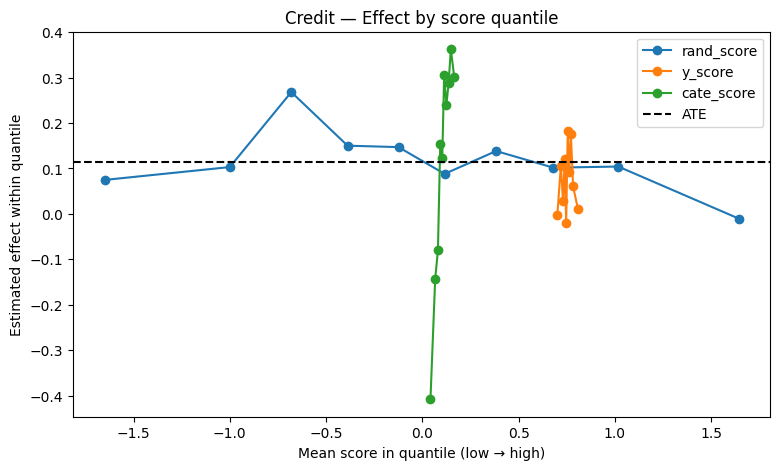

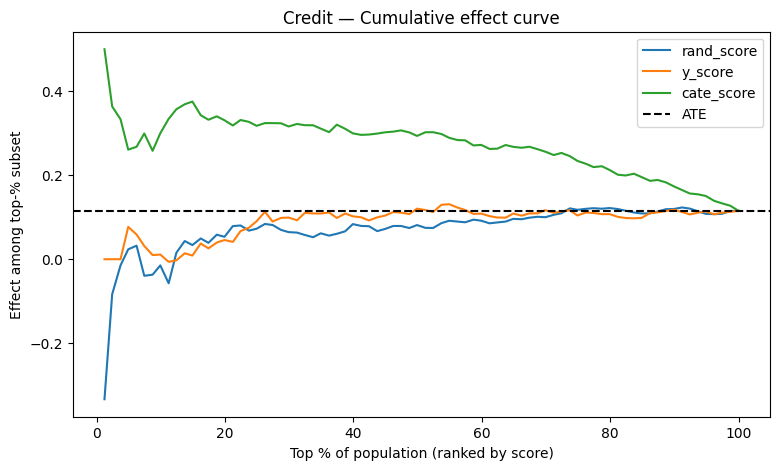

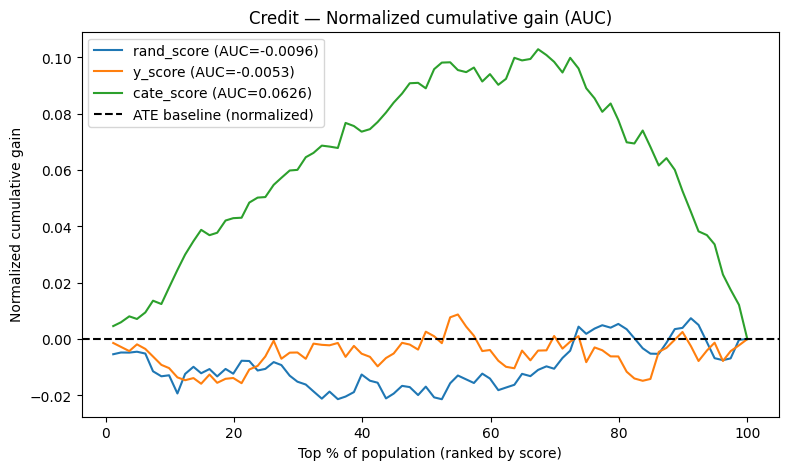

{'rand_score': np.float64(-0.009579854195870837),
 'y_score': np.float64(-0.005322435287123906),
 'cate_score': np.float64(0.06258574066502405)}

In [11]:

plot_effect_by_quantile(credit_scored, title="Credit — Effect by score quantile")
plot_cumulative_effect(credit_scored, title="Credit — Cumulative effect curve")
credit_aucs = plot_cumulative_gain(credit_scored, title="Credit — Normalized cumulative gain (AUC)")
credit_aucs


{'rand_score': np.float64(-0.009579854195870837),
     'y_score': np.float64(-0.005322435287123906),
     'cate_score': np.float64(0.06258574066502405)}


### Proxy Diagnostics for Treatment Effect Signal

Uses proxy outcomes to approximate treatment effect alignment.

Since individual causal effect is unobserved, proxy diagnostics help evaluate signal quality.


In [12]:

def pseudo_outcome_wmse_report(df: pd.DataFrame):
    y = df["y"].values.astype(float)
    t = df["t"].values.astype(float)
    e = df["e_hat"].values.astype(float)

    tau_tilde = pseudo_outcome_transformed(y, t, e, clip=1e-3)
    e_clip = np.clip(e, 1e-3, 1 - 1e-3)
    w = e_clip * (1 - e_clip)

    scores = {
        "rand_score": df["rand_score"].values.astype(float),
        "y_score": df["y_score"].values.astype(float),
        "cate_score": df["cate_score"].values.astype(float),
    }
    return {k: weighted_mse(tau_tilde, v, w) for k, v in scores.items()}

print("Bank pseudo-outcome weighted MSE:", pseudo_outcome_wmse_report(bank_scored))
print("Credit pseudo-outcome weighted MSE:", pseudo_outcome_wmse_report(credit_scored))


Bank pseudo-outcome weighted MSE: {'rand_score': np.float64(4.944346175875895), 'y_score': np.float64(4.637766410428871), 'cate_score': np.float64(3.926534698283044)}
Credit pseudo-outcome weighted MSE: {'rand_score': np.float64(4.3827211075593295), 'y_score': np.float64(3.8825831197706777), 'cate_score': np.float64(3.4307246359223136)}



## Key Takeaways

Heterogeneous Treatment Effect (HTE) modeling shows that treatment impact is not evenly distributed across customers, and that this variation can be exploited for better decisions.

From the results in this post:

- **CATE-based ranking consistently outperforms naive alternatives**  
  Across both the marketing and credit datasets, `cate_score` produces stronger cumulative effect and gain curves than either random ranking or outcome-based scoring.

- **Most of the treatment value is concentrated in top-ranked segments**  
  In both datasets, the cumulative effect curves show that a relatively small fraction of customers captures a disproportionate share of the treatment benefit.

- **Outcome-based ranking is not a good substitute for uplift modeling**  
  The `y_score` baseline performs near random and, in some cases, worse than random, showing that predicting outcomes is not the same as ranking treatment responsiveness.

- **The heterogeneity signal is real, but not equally stable everywhere**  
  The effect-by-quantile plots show that uplift signal is present in both datasets, but it is concentrated and noisy rather than smooth. This means the ranking is useful, even when individual bucket-level estimates are unstable.

- **Context matters**  
  The strength and shape of the uplift pattern differ between marketing and credit data, which suggests that heterogeneous treatment effects should be validated within each application rather than assumed to generalize uniformly.

---

### Practical implication

In real-world applications:

- use CATE models to **rank and prioritize customers**, rather than to estimate precise individual effects  
- validate ranking quality using **cumulative effect and gain curves**  
- compare against **random and outcome-based baselines** before trusting the model  
- expect heterogeneity to be **concentrated, noisy, and domain-specific**

The main lesson is:

> **Average treatment effects tell you whether something works overall.  
CATE tells you where the value is — and that is what drives targeting decisions.**
